## CHAMS STOCK PRICE PREDICTION


In [ ]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

chams=pd.read_csv('../stock_data/chams.csv') ## so it can be small letter. This is cool.
chams=chams.drop(columns=['high_price','low_price'])
chams.rename(columns={'trade_date':'date'},inplace=True)
chams['date']=pd.to_datetime(chams['date'])
chams['month']=chams['date'].dt.month
chams['quarter']=chams['date'].dt.quarter
chams['year']=chams['date'].dt.year

chams

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42839,CHAMS,2017-01-03,0.50,0.50,100000,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43399,CHAMS,2017-01-04,0.50,0.50,133079,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43509,CHAMS,2017-01-05,0.50,0.50,100000,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43619,CHAMS,2017-01-06,0.50,0.50,100000,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43709,CHAMS,2017-01-09,0.50,0.50,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298038,CHAMS,2026-07-13,4.44,4.44,10937479,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298476,CHAMS,2026-07-14,4.41,4.41,6746817,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298914,CHAMS,2026-07-15,4.37,4.37,9421036,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299352,CHAMS,2026-07-16,4.32,4.32,4101349,2026-07-16T15:10:03.113936+00:00,7,3,2026


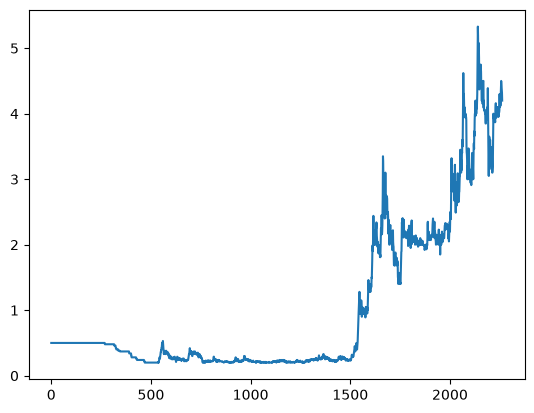

In [2]:
import matplotlib.pyplot as plt

plt.plot(chams['close_price'])
plt.show()

In [3]:
chams_end_month_df = (
    chams
    .sort_values("date")
    .groupby(chams["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

chams_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45409,CHAMS,2017-01-31,0.50,0.50,100000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47231,CHAMS,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49347,CHAMS,2017-03-31,0.50,0.50,10,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51174,CHAMS,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53097,CHAMS,2017-05-31,0.50,0.50,8000,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35275,CHAMS,2026-03-31,4.39,4.39,38557892,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281102,CHAMS,2026-04-30,3.49,3.49,23774239,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284168,CHAMS,2026-05-29,4.00,4.00,23670426,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294096,CHAMS,2026-06-30,4.30,4.30,25783296,2026-06-30T15:10:03.08168+00:00,6,2,2026


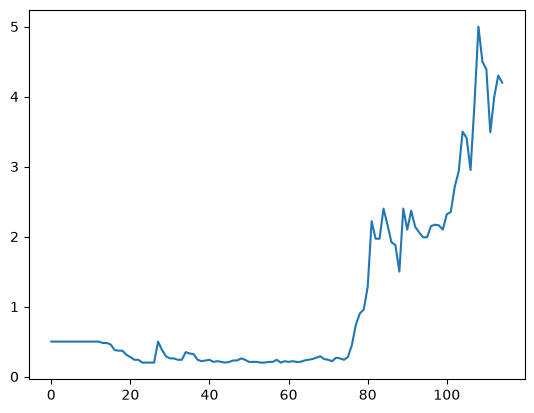

In [4]:
plt.plot(chams_end_month_df['close_price'])
plt.show()

In [5]:
chams_end_month_df['returns']=chams_end_month_df['close_price'].pct_change()*100
chams_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45409,CHAMS,2017-01-31,0.50,0.50,100000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47231,CHAMS,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49347,CHAMS,2017-03-31,0.50,0.50,10,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51174,CHAMS,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53097,CHAMS,2017-05-31,0.50,0.50,8000,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35275,CHAMS,2026-03-31,4.39,4.39,38557892,2026-03-31T15:00:02.085058+00:00,3,1,2026,-2.444444
111,281102,CHAMS,2026-04-30,3.49,3.49,23774239,2026-04-30T15:00:02.170664+00:00,4,2,2026,-20.501139
112,284168,CHAMS,2026-05-29,4.00,4.00,23670426,2026-05-29T15:00:02.455558+00:00,5,2,2026,14.613181
113,294096,CHAMS,2026-06-30,4.30,4.30,25783296,2026-06-30T15:10:03.08168+00:00,6,2,2026,7.500000


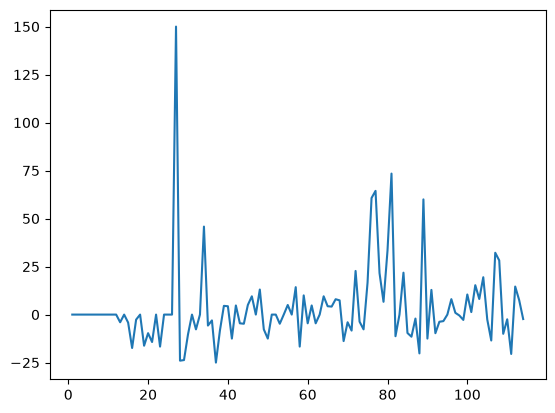

In [6]:
plt.plot(chams_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(chams_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.184073507094894), np.float64(6.578593676297812e-18), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(914.635081796747))
stationary


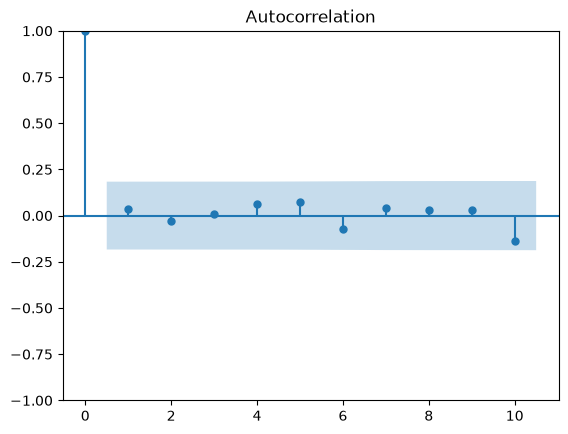

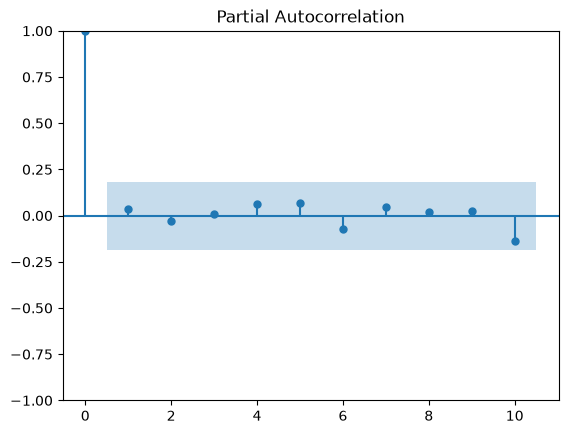

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(chams_end_month_df['returns'].dropna(), lags=10)
plot_pacf(chams_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=chams_end_month_df['close_price'][:-10]
test=chams_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -49.563177517195584]
[0, 0, 0, 0, 0, 1, -37.89667841550825]
[0, 0, 0, 0, 0, 2, -23.446166056457262]
[0, 0, 0, 0, 1, 0, -9.979808295702039]
[0, 0, 0, 0, 1, 1, -10.366410417160827]
[0, 0, 0, 0, 1, 2, -7.784332678954376]
[0, 0, 0, 0, 2, 0, -9.033622081054553]
[0, 0, 0, 0, 2, 1, -5.460355108419139]
[0, 0, 0, 0, 2, 2, -1.6159448828446101]
[0, 0, 0, 1, 0, 0, -12.509933231576229]
[0, 0, 0, 1, 0, 1, -14.994016168778778]
[0, 0, 0, 1, 0, 2, -13.14263686176757]
[0, 0, 0, 1, 1, 0, -9.734036368918842]
[0, 0, 0, 1, 1, 1, -8.82694975604585]
[0, 0, 0, 1, 1, 2, -7.142356220319835]
[0, 0, 0, 1, 2, 0, -1.070728795664384]
[0, 0, 0, 1, 2, 1, -2.0055197482452236]
[0, 0, 0, 1, 2, 2, -1.6281979781150113]
[0, 0, 0, 2, 0, 0, -13.594443555482998]
[0, 0, 0, 2, 0, 1, -13.709145873543187]
[0, 0, 0, 2, 0, 2, -13.954354251694726]
[0, 0, 0, 2, 1, 0, -7.39735693108619]
[0, 0, 0, 2, 1, 1, -8.277486141074192]
[0, 0, 0, 2, 1, 2, -7.818202076463596]
[0, 0, 0, 2, 2, 0, -1.9069998267701012]
[0, 0, 0, 2, 2,

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-171.163564
169,0,2,0,0,2,1,-69.976401
165,0,2,0,0,1,0,-63.367610
0,0,0,0,0,0,0,-49.563178
27,0,0,1,0,0,0,-46.749894
...,...,...,...,...,...,...,...
393,1,1,2,1,2,0,0.334247
150,0,1,2,1,2,0,0.347826
636,2,1,2,1,2,0,0.362635
609,2,1,1,1,2,0,0.363348


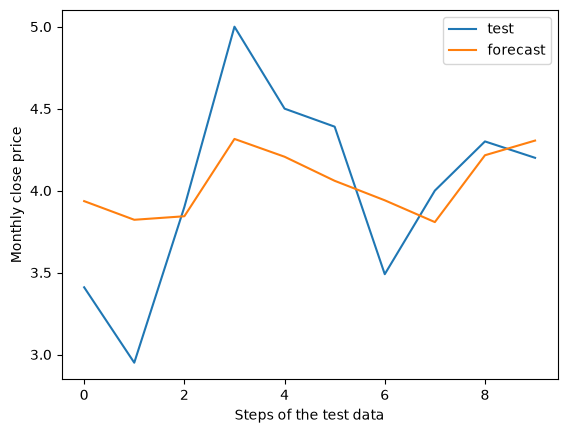

r2_score:  0.39635218660227334
rmse:  0.44298560447331303
description:  count    2263.000000
mean        1.030941
std         1.192761
min         0.200000
25%         0.230000
50%         0.370000
75%         2.000000
max         5.330000
Name: close_price, dtype: float64


In [12]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=chams_end_month_df['close_price'][:-10]
y_test=chams_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(1,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', chams.close_price.describe())

This is ok.